## Data from World Happiness Report

The World Happiness Report is an annual publication of the United Nations Sustainable Development Solutions Network. It contains articles, and rankings of national happiness based on respondent ratings of their own lives, which the report also correlates with various life factors.

In this notebook we will explore the happiness of different countries and the features associated.
The datasets that we will use are available in *Data*: **happiness2020.pkl** and **countries_info.csv**.

Although the features are self-explanatory, here a summary: 

**happiness2020.pkl**
* country: *Name of the country*
* happiness_score: *Happiness score*
* social_support: *Social support (mitigation the effects of inequality)*
* healthy_life_expectancy: *Healthy Life Expectancy*
* freedom_of_choices: *Freedom to make life choices*
* generosity: *Generosity (charity, volunteers)*
* perception_of_corruption: *Corruption Perception*
* world_region: *Area of the world of the country*

**countries_info.csv**
* country_name: *Name of the country*
* area: *Area in sq mi*
* population: *Number of people*
* literacy: *Literacy percentage*

In [1]:
!head Data/countries_info.csv

country_name,area,population,literacy
afghanistan,647500,31056997,"36,0"
albania,28748,3581655,"86,5"
algeria,2381740,32930091,"70,0"
argentina,2766890,39921833,"97,1"
armenia,29800,2976372,"98,6"
australia,7686850,20264082,"100,0"
austria,83870,8192880,"98,0"
azerbaijan,86600,7961619,"97,0"
bahrain,665,698585,"89,1"


In [2]:
import pandas as pd
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

## Task 1: Load the data

Load the 2 datasets in Pandas dataframes (called *happiness* and *countries*), and show the first rows.


**Hint**: Use the correct reader and verify the data has the expected format.

In [ ]:
# Write your code here
#happiness = pd.DataFrame(pd.read_csv(HAPPINESS_DATASET))
happiness = pd.read_csv(HAPPINESS_DATASET)

#countries = pd.DataFrame(pd.read_csv(COUNTRIES_DATASET, decimal=','))
countries = pd.read_csv(COUNTRIES_DATASET, decimal=',')


happiness.head(1)



,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
0,Afghanistan,2.5669,0.470367,52.59,0.396573,-0.096429,0.933687,South Asia


In [4]:
countries.head(1)

,country_name,area,population,literacy
0,afghanistan,647500,31056997,36.0


## Task 2: Let's merge the data

Create a dataframe called *country_features* by merging *happiness* and *countries*. A row of this dataframe must describe all the features that we have about a country.

**Hint**: Verify that all the rows are in the final dataframe.

In [5]:
# Write your code 
#put countrynames to lower case to match happiness dataset
#happiness['country'] = happiness['country'].str.lower()
happiness['country'] = happiness['country'].str.lower()

happiness.head(1)

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
0,afghanistan,2.5669,0.470367,52.59,0.396573,-0.096429,0.933687,South Asia


In [6]:
countries = countries.rename(columns={"country_name":"country"})
countries.head(1)


,country,area,population,literacy
0,afghanistan,647500,31056997,36.0


In [7]:
country_features = pd.merge(happiness,countries, on='country')
country_features.head(5)

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy
0,afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia,647500,31056997,36.0
1,albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe,28748,3581655,86.5
2,algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa,2381740,32930091,70.0
3,argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean,2766890,39921833,97.1
4,armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States,29800,2976372,98.6


In [29]:
print("happiness = {}".format(len(happiness)))
print("countries = {}".format(len(countries)))
print("country_features = {}".format(len(country_features)))

len(happiness) == len(countries) == len(country_features)

happiness = 135
countries = 135
country_features = 135


True

<span style="color:red"> **did happiness['country'] = happiness['country'].str.lower() — this overwrites the original column, so every later output shows finland, australia instead of Finland, Australia. The solution creates a temporary key column (country_name), merges on it, then drops it → original data untouched. General principle: don't destroy information just to build a join key.**</span>

**Get in the habit of checking shapes after every merge.**

## Task 3: Where are people happier?

Print the top 10 countries based on their happiness score (higher is better).

In [8]:
# Write your code here
country_features.sort_values(by=['happiness_score'],ascending=False).head(10)


,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy
38,finland,7.8087,0.954330,71.900825,0.949172,-0.059482,0.195445,Western Europe,338145,5231372,100.0
31,denmark,7.6456,0.955991,72.402504,0.951444,0.066202,0.168489,Western Europe,43094,5450661,100.0
115,switzerland,7.5599,0.942847,74.102448,0.921337,0.105911,0.303728,Western Europe,41290,7523934,99.0
50,iceland,7.5045,0.974670,73.000000,0.948892,0.246944,0.711710,Western Europe,103000,299388,99.9
92,norway,7.4880,0.952487,73.200783,0.955750,0.134533,0.263218,Western Europe,323802,4610820,100.0
87,netherlands,7.4489,0.939139,72.300919,0.908548,0.207612,0.364717,Western Europe,41526,16491461,99.0
114,sweden,7.3535,0.926311,72.600769,0.939144,0.111615,0.250880,Western Europe,449964,9016596,99.0
88,new zealand,7.2996,0.949119,73.202629,0.936217,0.191598,0.221139,North America and ANZ,268680,4076140,99.0
6,austria,7.2942,0.928046,73.002502,0.899989,0.085429,0.499955,Western Europe,83870,8192880,98.0
72,luxembourg,7.2375,0.906912,72.599998,0.905636,-0.004621,0.367084,Western Europe,2586,474413,100.0


In [34]:
country_features.sort_values("happiness_score", ascending=False)[['country', 'happiness_score']].head(10)

,country,happiness_score
38,finland,7.8087
31,denmark,7.6456
115,switzerland,7.5599
50,iceland,7.5045
92,norway,7.4880
87,netherlands,7.4489
114,sweden,7.3535
88,new zealand,7.2996
6,austria,7.2942
72,luxembourg,7.2375


We are interested to know in what world region people are happier. 

Create and print a dataframe with the (1) average happiness score and (2) the number of contries for each world region.
Sort the result to show the happiness ranking.

In [9]:
# Write your code here
country_features_mean = country_features.groupby(["world_region"])['happiness_score'].mean()



In [10]:
country_features_count = country_features.groupby(["world_region"])['country'].count()


In [11]:
country_features_by_region = pd.merge(country_features_mean,country_features_count, on='world_region')
country_features_by_region.sort_values(by=['happiness_score'],ascending=False)


,happiness_score,country
world_region,,
North America and ANZ,7.173525,4
Western Europe,6.967405,20
Latin America and Caribbean,5.971280,20
Central and Eastern Europe,5.891393,14
Southeast Asia,5.517788,8
East Asia,5.483633,3
Commonwealth of Independent States,5.358342,12
Middle East and North Africa,5.269306,16
Sub-Saharan Africa,4.393856,32


**Small side note: size counts rows, count counts non-NaN values; here identical, but not always.**

The first region has only a few countries! What are them and what is their score?

In [12]:
# Write your code here
mask = country_features['world_region'] == 'North America and ANZ'
mask.head(5)
country_features[mask].sort_values(by=['happiness_score'],ascending=False)

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy
88,new zealand,7.2996,0.949119,73.202629,0.936217,0.191598,0.221139,North America and ANZ,268680,4076140,99.0
21,canada,7.2321,0.927177,73.601601,0.933913,0.124771,0.390843,North America and ANZ,9984670,33098932,97.0
5,australia,7.2228,0.944855,73.604538,0.915432,0.190460,0.415169,North America and ANZ,7686850,20264082,100.0
127,united states,6.9396,0.914219,68.299500,0.842620,0.149892,0.699715,North America and ANZ,9631420,298444215,97.0


## Task 4: How literate is the world?

Print the names of the countries with a level of literacy of 100%. 

For each country, print the name and the world region in the format: *{region name} - {country name} ({happiness score})*

In [30]:
# Write your code here
mask = country_features['literacy'] == 100.0
mask.head(5)
#country_features[mask].sort_values(by=['happiness_score'],ascending=False)

#for _, row in country_features[mask].sort_values(by=['happiness_score'],ascending=False).iterrows():
for _, row in country_features[mask].iterrows():

    print(row['world_region'], " - ", row['country'], "({", row['happiness_score'], "})")
    print("{} - {} ({})".format(row.world_region, row.country, row.happiness_score))



North America and ANZ  -  australia ({ 7.222799778 })
North America and ANZ - australia (7.222799778)
Western Europe  -  denmark ({ 7.645599842 })
Western Europe - denmark (7.645599842)
Western Europe  -  finland ({ 7.808700085 })
Western Europe - finland (7.808700085)
Western Europe  -  luxembourg ({ 7.237500191 })
Western Europe - luxembourg (7.237500191)
Western Europe  -  norway ({ 7.487999916000001 })
Western Europe - norway (7.487999916000001)


What is the global average?

In [14]:
# Write your code here
print(country_features['literacy'].mean())


81.85112781954888


Calculate the proportion of countries with a literacy level below 50%. Print the value in percentage, formatted with 2 decimals.

In [32]:
# Write your code here
mask = country_features['literacy'] < 50
f"Proportion of countries with a literacy level below 50%: {(mask.sum()/len(country_features))*100:.2f}%"


'Proportion of countries with a literacy level below 50%: 11.85%'

In [33]:
percentage = len(country_features[country_features.literacy<50])/len(country_features)
print("Percentage of countries with literacy level < 50%: {:.2%}".format(percentage))

Percentage of countries with literacy level < 50%: 11.85%


Print the raw number and the percentage of world population that is illiterate.

In [16]:
# Write your code here
illiterate_per_country = country_features['population'] * (1-(country_features['literacy']/100))
total_illiterate = illiterate_per_country.sum()
percentage = (total_illiterate/country_features['population'].sum())*100

print(f"Raw number is illiterate:{total_illiterate:.0f} and perctentage on world pop: {percentage:.2f}%")

Raw number is illiterate:1249372988 and perctentage on world pop: 20.33%


## Task 5: Population density

Add to the dataframe a new field called *population_density* computed by dividing *population* by *area*.

In [17]:
# Write your code here
country_features['population_density'] = country_features['population'] / country_features['area']

country_features.head(10)

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy,population_density
0,afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia,647500,31056997,36.0,47.964474
1,albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe,28748,3581655,86.5,124.587971
2,algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa,2381740,32930091,70.0,13.826065
3,argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean,2766890,39921833,97.1,14.428413
4,armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States,29800,2976372,98.6,99.878255
5,australia,7.2228,0.944855,73.604538,0.915432,0.190460,0.415169,North America and ANZ,7686850,20264082,100.0,2.636201
6,austria,7.2942,0.928046,73.002502,0.899989,0.085429,0.499955,Western Europe,83870,8192880,98.0,97.685466
7,azerbaijan,5.1648,0.819308,65.508400,0.786824,-0.240255,0.552538,Commonwealth of Independent States,86600,7961619,97.0,91.935554
8,bahrain,6.2273,0.876342,68.500000,0.905856,0.133729,0.739347,Middle East and North Africa,665,698585,89.1,1050.503759
9,bangladesh,4.8328,0.687293,64.503067,0.900625,-0.033665,0.661844,South Asia,144000,147365352,43.1,1023.370500


What is the happiness score of the 3 countries with the lowest population density?

In [18]:
# Write your code here
mask = country_features.sort_values(by=['population_density'],ascending=True).head(3)
for _, row in mask.iterrows():
    print(row['country'], " has population_density of ", row['population_density'], " and has happiness score of", row['happiness_score'])


    

mongolia  has population_density of  1.810750609289848  and has happiness score of 5.4562001229999995
australia  has population_density of  2.6362010446411728  and has happiness score of 7.222799778
botswana  has population_density of  2.7313706547628964  and has happiness score of 3.478899956


## Task 6: Healty and happy?

Plot in a scatter plot the happiness score (x) and healty life expectancy (y).

,happiness_score,healthy_life_expectancy
happiness_score,1.00000,0.78755
healthy_life_expectancy,0.78755,1.00000


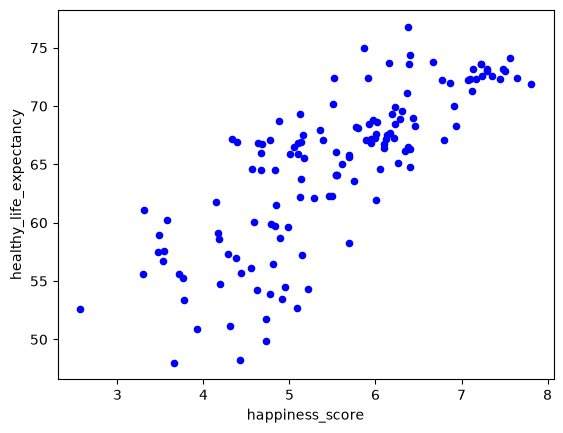

In [23]:
# Write your code here
country_features.plot.scatter(x='happiness_score', y='healthy_life_expectancy', c="blue")
country_features[['happiness_score','healthy_life_expectancy']].corr()

In [25]:
country_features.plot.scatter?

Signature:
country_features.plot.scatter(
    x: 'Hashable',
    y: 'Hashable',
    s: 'Hashable | Sequence[Hashable] | None' = None,
    c: 'Hashable | Sequence[Hashable] | None' = None,
    **kwargs,
) -> 'PlotAccessor'
Docstring:
Create a scatter plot with varying marker point size and color.

The coordinates of each point are defined by two dataframe columns and
filled circles are used to represent each point. This kind of plot is
useful to see complex correlations between two variables. Points could
be for instance natural 2D coordinates like longitude and latitude in
a map or, in general, any pair of metrics that can be plotted against
each other.

Parameters
----------
x : int or str
    The column name or column position to be used as horizontal
    coordinates for each point.
y : int or str
    The column name or column position to be used as vertical
    coordinates for each point.
s : str, scalar or array-like, optional
    The size of each point. Possible values are:

    -

<Axes: title={'center': 'Healty and happy?'}, xlabel='Happiness Score', ylabel='Healthy Life Expectancy'>

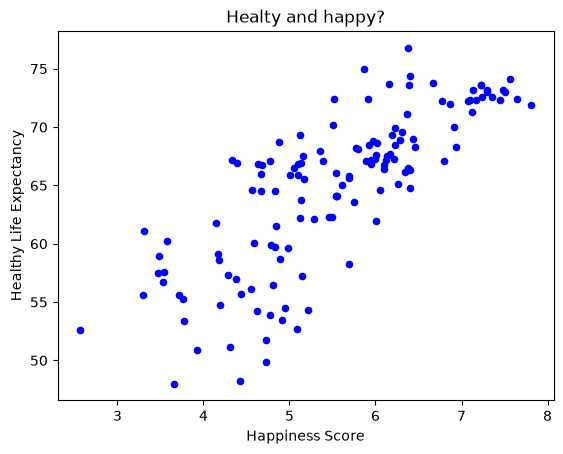

In [27]:
country_features.plot.scatter(x='happiness_score', y='healthy_life_expectancy', c="blue", title='Healty and happy?', xlabel='Happiness Score',ylabel='Healthy Life Expectancy')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

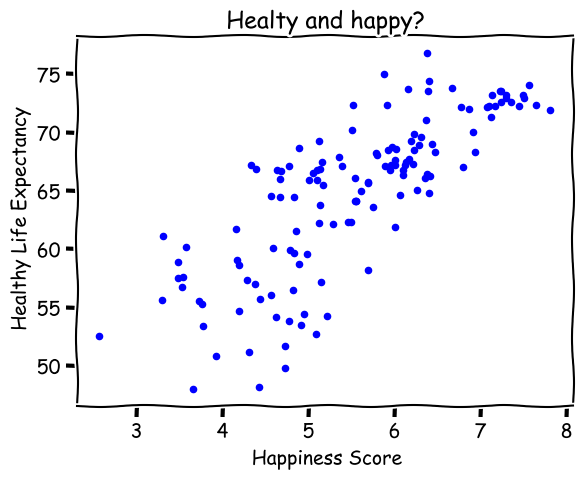

In [28]:
import matplotlib.pyplot as plt
with plt.xkcd():
    country_features.plot.scatter(x='happiness_score', y='healthy_life_expectancy', c="blue", title='Healty and happy?', xlabel='Happiness Score',ylabel='Healthy Life Expectancy')


Feel free to continue the exploration of the dataset! We'll release the solutions next week.

----
Enjoy EPFL and be happy, next year Switzerland must be #1.